# PTB-XL — Tidy, Modular Notebook (v2, updated)

# 0) Config — paths, toggles, label mode

In [1]:
# -------- Global Config --------
CFG = {
    # Root folder that contains ptbxl_database.csv, scp_statements.csv, and records100/
    "PTBXL_ROOT": "dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3",
    # 'filename_lr' (100 Hz) or 'filename_hr' (500 Hz)
    "RECORD_FILE_COL": "filename_lr",
    # Label granularity: '5class' uses diagnostic_class; '10class' uses diagnostic_subclass
    "LABEL_MODE": "5class",
    # Fast mode: limit records & skip DL/FL
    "FAST_RUN": False,               # set True for quick smoke-tests
    "MAX_RECORDS": None,             # e.g., 200 in FAST_RUN
    "USE_FEATURE_CACHE": True,       # reuse feature CSV if present
    # Artifacts
    "ART_DIR": "test/artifacts",
    "CACHE_DIR": "./sk_cache",
    # Extended EDA heavies (VIF/PCA); set True to skip on big runs
    "EDA_SKIP_HEAVY": False,
    # Random seed
    "SEED": 42,
}
if CFG["FAST_RUN"] and (CFG["MAX_RECORDS"] is None):
    CFG["MAX_RECORDS"] = 200  # sensible default for quick runs
print(CFG)

{'PTBXL_ROOT': 'dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3', 'RECORD_FILE_COL': 'filename_lr', 'LABEL_MODE': '5class', 'FAST_RUN': False, 'MAX_RECORDS': None, 'USE_FEATURE_CACHE': True, 'ART_DIR': 'test/artifacts', 'CACHE_DIR': './sk_cache', 'EDA_SKIP_HEAVY': False, 'SEED': 42}


# 1) Setup & Reproducibility

In [2]:
import os, random, time, json, warnings, ast, itertools, zipfile, glob, sys, subprocess
import numpy as np
import pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore")

SEED = CFG["SEED"]
random.seed(SEED); np.random.seed(SEED)

# Torch is optional
try:
    import torch
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    TORCH_OK = True
except Exception:
    TORCH_OK = False

def ts() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")

def log(msg: str):
    print(f"[{ts()}] {msg}")

# show key library versions
try:
    from importlib.metadata import version
    log("Versions — pandas %s, numpy %s" % (version("pandas"), version("numpy")))
except Exception:
    pass

log(f"Seeds set. Torch available: {TORCH_OK}")

[2025-10-06 21:45:58] Versions — pandas 2.3.2, numpy 2.3.3
[2025-10-06 21:45:58] Seeds set. Torch available: True


# 2) Paths & Sanity Checks

In [3]:
from pathlib import Path
from scipy.stats import skew, kurtosis

ROOT = Path(CFG["PTBXL_ROOT"])
DB_CSV  = ROOT / "ptbxl_database.csv"
SCP_CSV = ROOT / "scp_statements.csv"
RECORDS_DIR = ROOT / "records100"  # required for filename_lr

assert DB_CSV.exists(),  f"Missing {DB_CSV}"
assert SCP_CSV.exists(), f"Missing {SCP_CSV}"
assert RECORDS_DIR.exists(), "Missing records100/ (for low-rate signals)"

# WFDB required for signal reading
try:
    import wfdb
except ImportError as e:
    raise RuntimeError("Please install WFDB:  %pip install wfdb") from e

# sanity read (not fatal)
try:
    sig0, meta0 = wfdb.rdsamp(str(RECORDS_DIR / "00000" / "00001_lr"))
    log(f"WFDB sanity OK: shape={sig0.shape}, leads={meta0.get('sig_name', [])}")
except Exception as e:
    log(f"WFDB sanity read failed (not fatal): {e}")

[2025-10-06 21:45:58] WFDB sanity OK: shape=(1000, 12), leads=['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


# 3) Load CSVs

In [4]:
db  = pd.read_csv(DB_CSV)
scp_raw = pd.read_csv(SCP_CSV, encoding="utf-8-sig")
scp_raw.columns = [str(c).strip() for c in scp_raw.columns]
log(f"Loaded db: {db.shape}, scp_statements: {scp_raw.shape}")
display(db.head(2)); display(scp_raw.head(2))

[2025-10-06 21:45:59] Loaded db: (21799, 28), scp_statements: (71, 13)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN


# 4) Target Mapping (SCP → 5-class or 10-class)

In [5]:
# --- utilities to identify the code column and filter diagnostic rows ---
def _extract_scp_keys(db_series, n=2000):
    keys = set()
    for s in db_series.head(min(n, len(db_series))):
        try:
            d = ast.literal_eval(s); keys.update(map(str, d.keys()))
        except Exception:
            pass
    return keys

known_keys = _extract_scp_keys(db["scp_codes"], n=2000)
candidates = [c for c in scp_raw.columns if scp_raw[c].dtype == "object"]
scores = {c: len(set(scp_raw[c].astype(str)).intersection(known_keys)) for c in candidates}
code_col = max(scores, key=scores.get) if scores and max(scores.values())>0 else scp_raw.columns[0]

scp_raw["code"] = scp_raw[code_col].astype(str)
scp = scp_raw.set_index("code", drop=False); scp.index.name = "code"

for req in ["diagnostic", "diagnostic_class", "diagnostic_subclass"]:
    if req not in scp.columns:
        raise ValueError(f"scp_statements.csv missing required column: '{req}'")

# normalize 'diagnostic' (1/True/yes/1.0 all treated as diagnostic)
diag_col = scp["diagnostic"]
diag_mask_num = pd.to_numeric(diag_col, errors="coerce").fillna(0) > 0
diag_mask_str = diag_col.astype(str).str.strip().str.lower().isin(["1","1.0","true","t","yes","y","on"])
diag_mask = diag_mask_num | diag_mask_str

label_field = "diagnostic_class" if CFG["LABEL_MODE"] == "5class" else "diagnostic_subclass"
diag_only = scp.loc[diag_mask, ["diagnostic_class", "diagnostic_subclass"]].copy()
valid_codes = set(diag_only.index)

log(f"Diagnostic SCP codes detected: {len(valid_codes)} / {len(scp)}")
if len(valid_codes) == 0:
    raise RuntimeError("No diagnostic codes detected — check scp_statements.csv 'diagnostic'.")

def to_diag_label(scp_codes_dict, min_conf=0.0):
    """
    Weighted-by-confidence mapping:
    Sum confidences per diagnostic class/subclass and pick the argmax.
    """
    try:
        items = [(str(k), float(v)) for k, v in scp_codes_dict.items()]
    except Exception:
        return None
    items = [(k, v) for k, v in items if k in valid_codes and v >= min_conf]
    if not items:
        return None
    lab_weights = {}
    for k, w in items:
        lab = diag_only.loc[k, label_field]
        lab_weights[lab] = lab_weights.get(lab, 0.0) + w
    return max(lab_weights.items(), key=lambda kv: kv[1])[0]

[2025-10-06 21:45:59] Diagnostic SCP codes detected: 44 / 71


# 5) Feature Extraction (WFDB)

In [6]:
from typing import Dict, Any, List
from joblib import Parallel, delayed

OUT_CSV = ROOT / "ptbxl_features.csv"

META_FIELDS = [
    "ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
    "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
    "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
    "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
    "pacemaker","strat_fold"
]

def _one_row(r: dict) -> dict | None:
    feats: Dict[str, Any] = {}
    # meta
    for k in META_FIELDS:
        val = r.get(k, np.nan)
        if k == "recording_date":
            try: feats[k] = pd.to_datetime(val).date().isoformat()
            except Exception: feats[k] = np.nan
        else:
            feats[k] = val
    # target
    try:
        scp_codes = ast.literal_eval(r.get("scp_codes", "{}"))
    except Exception:
        return None
    y = to_diag_label(scp_codes)
    if y is None:
        return None
    # read signal
    rec_dat   = ROOT / r[CFG["RECORD_FILE_COL"]]  # e.g., records100/.../_lr.dat
    rec_noext = str(rec_dat)[:-4] if str(rec_dat).endswith(".dat") else str(rec_dat)
    try:
        sig, meta = wfdb.rdsamp(rec_noext)  # (T, 12 leads)
    except Exception:
        return None
    feats["record_path"] = rec_noext
    for j in range(sig.shape[1]):
        x = sig[:, j].astype(np.float32)
        feats[f"L{j}_mean"] = float(np.mean(x))
        feats[f"L{j}_std"]  = float(np.std(x, ddof=1)) if len(x) > 1 else 0.0
        feats[f"L{j}_rms"]  = float(np.sqrt(np.mean(x**2)))
        feats[f"L{j}_p25"]  = float(np.percentile(x, 25))
        feats[f"L{j}_p50"]  = float(np.percentile(x, 50))
        feats[f"L{j}_p75"]  = float(np.percentile(x, 75))
        try:   feats[f"L{j}_skew"] = float(skew(x))
        except: feats[f"L{j}_skew"] = 0.0
        try:   feats[f"L{j}_kurt"] = float(kurtosis(x))
        except: feats[f"L{j}_kurt"] = 0.0
    feats["label"] = y
    return feats

def extract_features(db: pd.DataFrame, file_col: str, max_records=None) -> pd.DataFrame:
    rows = db.to_dict(orient="records")
    if max_records is not None:
        rows = rows[:max_records]
    results = Parallel(n_jobs=-1, prefer="threads")(delayed(_one_row)(r) for r in rows)
    results = [r for r in results if r is not None]
    if not results:
        raise RuntimeError("Feature extraction produced 0 rows. Check mappings and file paths.")
    df = pd.DataFrame(results)
    log(f"Extracted features: n={len(df)}")
    return df

if OUT_CSV.exists() and CFG["USE_FEATURE_CACHE"]:
    features_df = pd.read_csv(OUT_CSV)
    log(f"Using cached features: {OUT_CSV} ({features_df.shape})")
else:
    features_df = extract_features(db, CFG["RECORD_FILE_COL"], CFG["MAX_RECORDS"])
    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    features_df.to_csv(OUT_CSV, index=False)
    log(f"Saved features → {OUT_CSV}")

display(features_df.head())
print("Class counts:\n", features_df["label"].value_counts())

[2025-10-06 21:45:59] Using cached features: dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_features.csv ((21388, 124))


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,L10_kurt,L11_mean,L11_std,L11_rms,L11_p25,L11_p50,L11_p75,L11_skew,L11_kurt,label
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09,...,12.147693,0.000832,0.101990,0.101943,-0.069,-0.0110,0.03300,1.839972,5.115987,NORM
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14,...,27.429422,0.003389,0.186720,0.186657,-0.094,-0.0215,0.02500,4.224206,24.103996,NORM
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15,...,19.571331,0.004239,0.100892,0.100931,-0.060,-0.0130,0.05325,2.914357,13.329775,NORM
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15,...,8.050313,-0.004061,0.298061,0.297940,-0.182,-0.0790,0.08800,2.007729,6.758060,NORM
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17,...,19.030163,-0.000053,0.180299,0.180209,-0.093,-0.0440,0.00900,4.030639,20.116993,NORM


Class counts:
 label
NORM    9243
MI      4049
CD      3431
STTC    3360
HYP     1305
Name: count, dtype: int64


# 6) EDA (basic)

,count,mean,std,min,25%,50%,75%,max
ecg_id,21388.0,10891.272115,6300.265743,1.000000,5431.750000,10862.500000,16349.250000,21837.000000
patient_id,21388.0,11210.154432,6240.997937,302.000000,5915.750000,11360.500000,16568.250000,21797.000000
age,21388.0,62.608753,32.235489,2.000000,50.000000,62.000000,72.000000,300.000000
sex,21388.0,0.480503,0.499631,0.000000,0.000000,0.000000,1.000000,1.000000
height,6918.0,166.694565,10.869989,6.000000,160.000000,166.000000,174.000000,209.000000
weight,9366.0,71.020500,15.877360,5.000000,60.000000,70.000000,80.000000,250.000000
nurse,19949.0,2.313900,3.261345,0.000000,0.000000,1.000000,4.000000,11.000000
site,21372.0,1.558675,4.201119,0.000000,0.000000,1.000000,2.000000,50.000000
validated_by,12296.0,0.745690,1.179663,0.000000,0.000000,1.000000,1.000000,11.000000
strat_fold,21388.0,5.502992,2.875975,1.000000,3.000000,6.000000,8.000000,10.000000


pacemaker              0.999345
electrodes_problems    0.998691
infarction_stadium2    0.995184
burst_noise            0.972835
baseline_drift         0.926174
extra_beats            0.912007
static_noise           0.850103
infarction_stadium1    0.738171
height                 0.676548
weight                 0.562091
validated_by           0.425098
heart_axis             0.381522
nurse                  0.067281
site                   0.000748
L10_skew               0.000047
L10_kurt               0.000047
L7_std                 0.000000
L8_rms                 0.000000
L8_std                 0.000000
L7_rms                 0.000000
dtype: float64

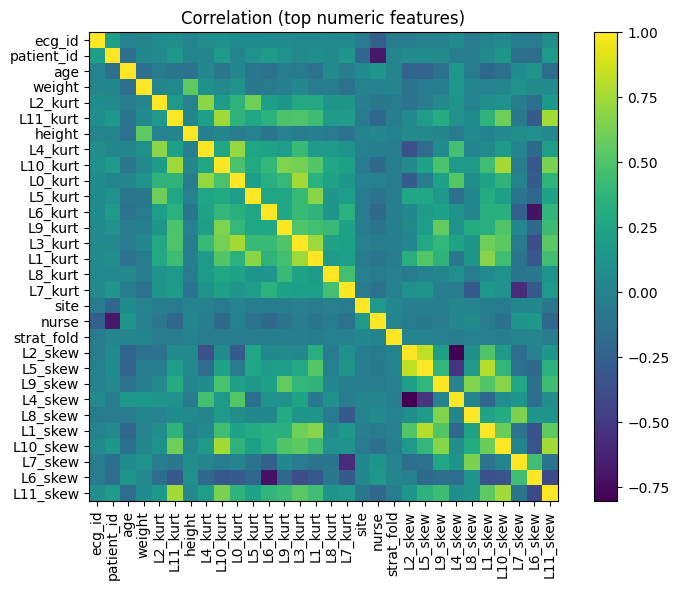

In [7]:
display(features_df.describe().T.iloc[:12])
na_rate = features_df.isna().mean().sort_values(ascending=False)
display(na_rate.head(20))

import matplotlib.pyplot as plt
num_df = features_df.select_dtypes(include=[np.number]).copy()
var = num_df.var().sort_values(ascending=False)
top_cols = var.index[:30] if len(var) >= 30 else var.index
corr = num_df[top_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.title("Correlation (top numeric features)")
plt.xticks(range(len(top_cols)), top_cols, rotation=90)
plt.yticks(range(len(top_cols)), top_cols)
plt.colorbar(); plt.tight_layout(); plt.show()

# 7.0) Extended EDA — setup & helpers

In [8]:
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score
from scipy.stats import chi2_contingency

ART_DIR = Path(CFG["ART_DIR"]); ART_DIR.mkdir(parents=True, exist_ok=True)
df_ext = features_df.copy()

def _downsampled_axis(ax, labels):
    n = len(labels); max_ticks = 40
    if n > max_ticks:
        step = max(1, n // max_ticks); idxs = list(range(0, n, step))
        ax.set_xticks(idxs); ax.set_yticks(idxs)
        ax.set_xticklabels([labels[i] for i in idxs], rotation=90)
        ax.set_yticklabels([labels[i] for i in idxs])
    else:
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(labels, rotation=90); ax.set_yticklabels(labels)

def _plot_corr(corr: pd.DataFrame, title: str):
    cm = corr.copy()
    mask = np.triu(np.ones(cm.shape, dtype=bool), 1)
    cm_masked = cm.mask(mask).fillna(0.0)
    fig, ax = plt.subplots(figsize=(12,9))
    im = ax.imshow(cm_masked.values, aspect="auto", interpolation="nearest")
    ax.set_title(title); ax.set_xlabel("Features"); ax.set_ylabel("Features")
    _downsampled_axis(ax, list(cm_masked.columns))
    fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

def _top_abs_pairs(corr: pd.DataFrame, n: int = 30) -> pd.DataFrame:
    cm = corr.abs().to_numpy(); cols = corr.columns.to_numpy()
    i, j = np.triu_indices_from(cm, k=1)
    pairs = pd.DataFrame({"f1": cols[i], "f2": cols[j], "|r|": cm[i, j]})
    return pairs.sort_values("|r|", ascending=False).head(n)

def _cramers_v_matrix(df_cat: pd.DataFrame) -> pd.DataFrame:
    cats = [c for c in df_cat.columns if df_cat[c].nunique(dropna=True) > 1]
    n = len(cats); out = pd.DataFrame(np.eye(n), index=cats, columns=cats, dtype=float)
    for a_i in range(n):
        for b_i in range(a_i+1, n):
            a, b = cats[a_i], cats[b_i]
            tbl = pd.crosstab(df_cat[a], df_cat[b])
            if tbl.shape[0] < 2 or tbl.shape[1] < 2:
                v = np.nan
            else:
                chi2, _, _, _ = chi2_contingency(tbl, correction=False)
                nobs = float(tbl.values.sum())
                r, k = tbl.shape
                phi2 = chi2 / max(nobs, 1.0)
                phi2corr = max(0.0, phi2 - (k-1)*(r-1)/max(nobs-1, 1.0))
                rcorr = r - (r-1)**2 / max(nobs-1, 1.0)
                kcorr = k - (k-1)**2 / max(nobs-1, 1.0)
                denom = min((kcorr-1), (rcorr-1))
                v = np.sqrt(phi2corr / denom) if denom and denom > 0 else np.nan
            out.iloc[a_i, b_i] = out.iloc[b_i, a_i] = v
    return out

def _mutual_info(df_in: pd.DataFrame, target: str) -> pd.Series:
    if target not in df_in.columns:
        raise ValueError(f"Target '{target}' not found.")
    y = df_in[target]; X = df_in.drop(columns=[target])
    X_num = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
    X_cat = X.select_dtypes(include=["object", "category", "bool"]).copy()
    for c in X_cat.columns:
        X_cat[c] = LabelEncoder().fit_transform(X_cat[c].astype(str))
    parts = []
    if not X_num.empty:
        X_num = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_num), columns=X_num.columns, index=X.index)
        parts.append(X_num)
    if not X_cat.empty:
        X_cat = pd.DataFrame(SimpleImputer(strategy="most_frequent").fit_transform(X_cat), columns=X_cat.columns, index=X.index)
        parts.append(X_cat)
    if not parts: raise ValueError("No usable features for MI.")
    X_imp = pd.concat(parts, axis=1)
    var = X_imp.var(axis=0); keep = var[var>0].index
    X_imp = X_imp[keep]

    if y.dtype.kind in "ifu":
        y_num = pd.to_numeric(y, errors="coerce").replace([np.inf, -np.inf], np.nan)
        mask = y_num.notna()
        mi_vals = mutual_info_regression(X_imp.loc[mask], y_num.loc[mask], random_state=42)
    else:
        y_enc = LabelEncoder().fit_transform(y.astype(str))
        mi_vals = mutual_info_classif(X_imp, y_enc, random_state=42)
    return pd.Series(mi_vals, index=X_imp.columns).sort_values(ascending=False)

# 7.1) Pearson — all numeric

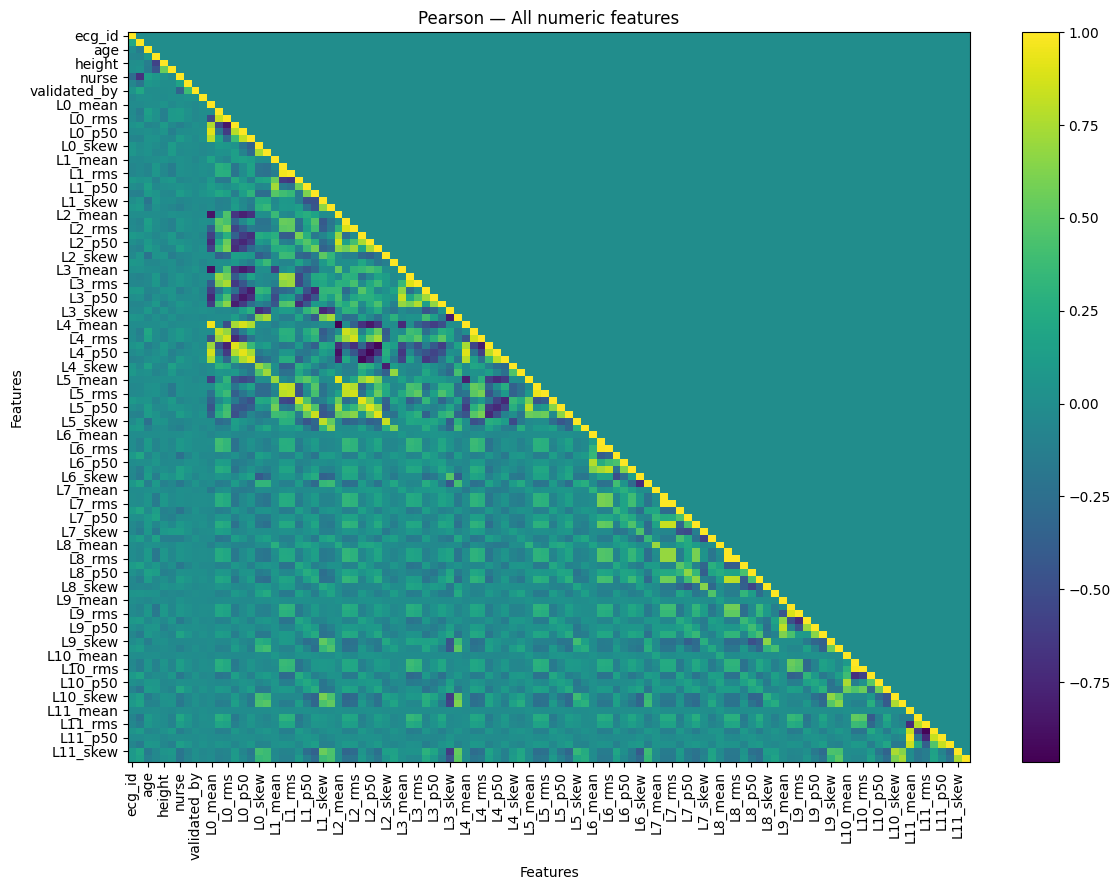

,f1,f2,|r|
5100,L8_std,L8_rms,0.998922
4824,L7_std,L7_rms,0.998251
4484,L6_std,L6_rms,0.979619
5460,L10_std,L10_rms,0.970992
5540,L11_mean,L11_p50,0.965862
2420,L2_mean,L4_mean,0.964317
1824,L1_std,L1_rms,0.963509
1036,L0_mean,L4_mean,0.959682
4080,L5_std,L5_rms,0.942678
5550,L11_rms,L11_p25,0.940883


In [9]:
num = df_ext.select_dtypes(include=[np.number])
if num.shape[1] > 1:
    corr_all = num.corr(method="pearson")
    corr_all.to_csv(ART_DIR / "corr_all_numeric.csv", index=True)
    _plot_corr(corr_all, "Pearson — All numeric features")
    top30 = _top_abs_pairs(corr_all)
    top30.to_csv(ART_DIR / "top30_abs_corr_all_numeric.csv", index=False)
    display(top30.head(10))
else:
    log("Not enough numeric columns for Pearson correlation.")

# 7.2) Pearson — numeric + age/sex

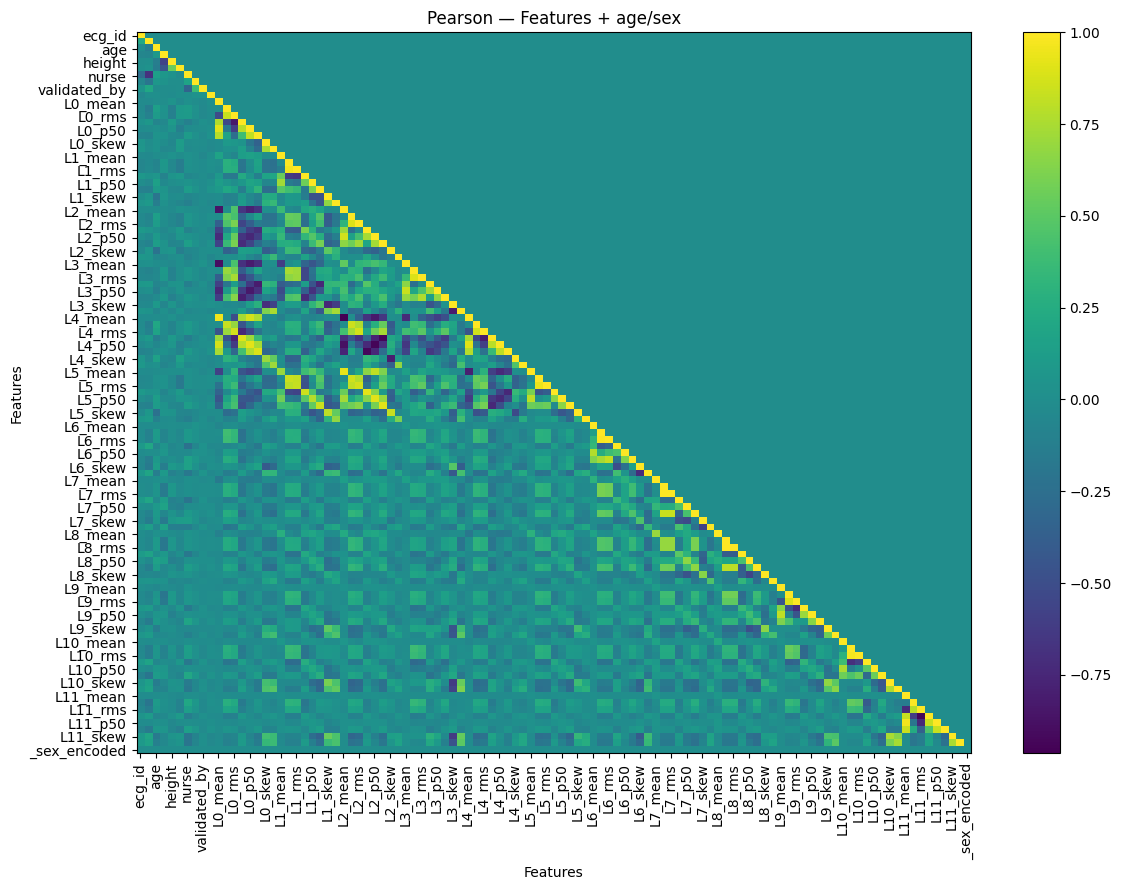

In [10]:
_df_tmp = df_ext.copy()
if "sex" in _df_tmp.columns:
    _df_tmp["_sex_encoded"] = _df_tmp["sex"].astype(str).str.lower().str.strip().map({"male":0,"m":0,"female":1,"f":1})
keep = list(_df_tmp.select_dtypes(include=[np.number]).columns)
for extra in ["age", "_sex_encoded"]:
    if extra in _df_tmp.columns and extra not in keep: keep.append(extra)
num_meta = _df_tmp[keep]
if num_meta.shape[1] > 1:
    corr_meta = num_meta.corr(method="pearson")
    corr_meta.to_csv(ART_DIR / "corr_features_plus_age_sex.csv", index=True)
    _plot_corr(corr_meta, "Pearson — Features + age/sex")
else:
    log("Not enough numeric columns for extended Pearson (+age/sex).")

# 7.3) Cramér’s V — categorical associations

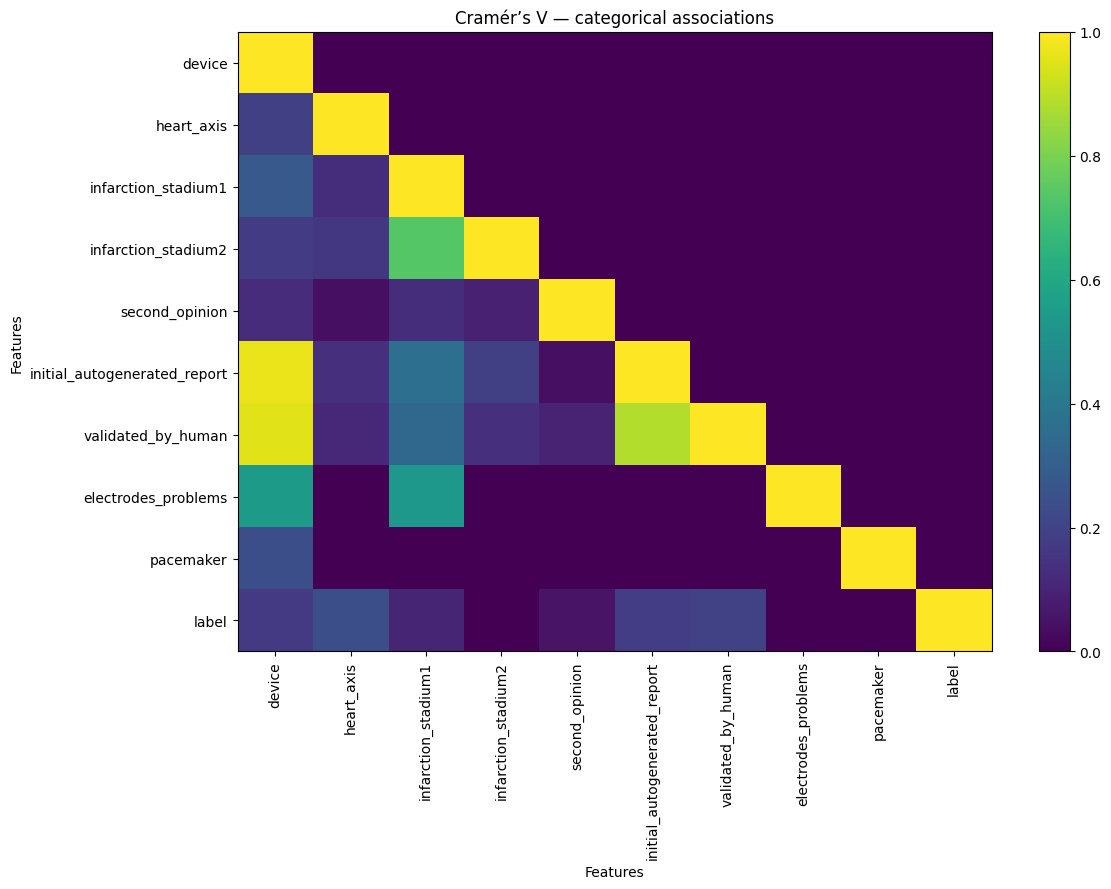

In [11]:
cat_cols = df_ext.select_dtypes(include=["object","category","bool"]).columns.tolist()
cat_keep = [c for c in cat_cols if 2 <= df_ext[c].nunique(dropna=True) <= 50]
if len(cat_keep) >= 2:
    cram = _cramers_v_matrix(df_ext[cat_keep])
    cram.to_csv(ART_DIR / "cramers_v_matrix.csv", index=True)
    _plot_corr(cram.fillna(0.0), "Cramér’s V — categorical associations")
else:
    log("No suitable categorical columns (2–50 unique) for Cramér’s V.")

# 7.4) Mutual Information — mixed types → target

In [12]:
target_candidates = [c for c in ["label","diagnostic_class","superclass","target"] if c in df_ext.columns]
if target_candidates:
    tgt = target_candidates[0]; log(f"Computing MI target={tgt}")
    try:
        mi = _mutual_info(df_ext.dropna(subset=[tgt], how="all"), tgt)
        mi.head(30).to_csv(ART_DIR / "mi_top30.csv")
        display(mi.head(20))
    except Exception as e:
        log(f"MI skipped: {e}")
else:
    log("No obvious target column for MI (e.g., 'label').")

[2025-10-06 21:46:01] Computing MI target=label


scp_codes              1.336137
report                 0.715179
infarction_stadium1    0.389109
L1_skew                0.116837
L9_p50                 0.106539
L1_p50                 0.104568
L3_skew                0.101744
heart_axis             0.098717
L3_p50                 0.096728
L8_p50                 0.091658
patient_id             0.087883
age                    0.086819
L9_skew                0.086703
L10_p50                0.085368
L5_skew                0.083755
L8_p25                 0.082715
L9_p25                 0.082134
L5_p50                 0.081859
L1_p25                 0.079381
L3_kurt                0.079245
dtype: float64

# 7.5) Temporal drift — class prevalence by month

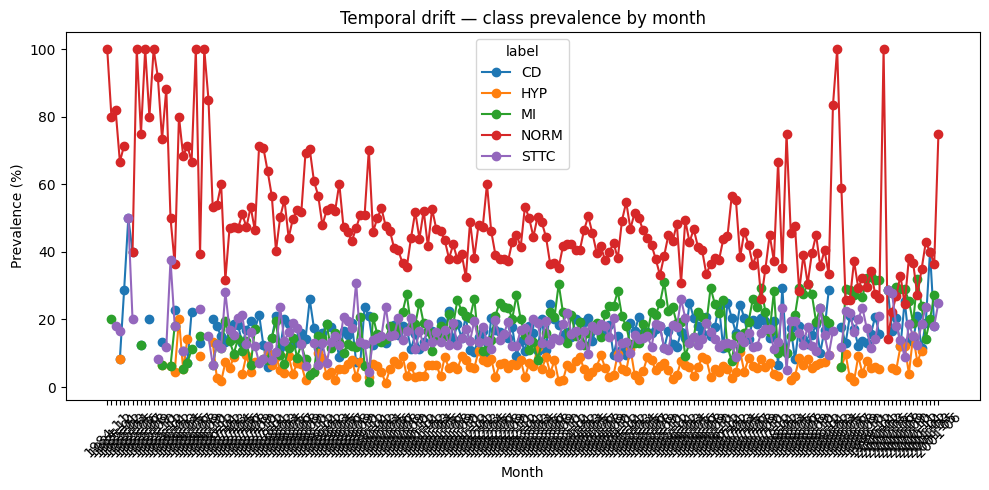

In [13]:
_df = df_ext.copy()
if "recording_date" in _df.columns:
    _df["recording_dt"] = pd.to_datetime(_df["recording_date"], errors="coerce")
else:
    _df["recording_dt"] = pd.NaT
_df["ym"] = _df["recording_dt"].dt.to_period("M").astype(str)
counts = (_df.groupby(["ym","label"], as_index=False).size().rename(columns={"size":"n"}))
counts = counts[counts["ym"].notna()].copy()
counts["pct"] = counts["n"] / counts.groupby("ym")["n"].transform("sum") * 100

plt.figure(figsize=(10,5))
for c in sorted(counts["label"].dropna().unique()):
    m = counts["label"]==c
    ser = counts.loc[m, ["ym","pct"]].set_index("ym").reindex(sorted(counts["ym"].unique()))
    plt.plot(ser.index, ser["pct"].values, marker="o", label=str(c))
plt.title("Temporal drift — class prevalence by month")
plt.xlabel("Month"); plt.ylabel("Prevalence (%)")
plt.legend(title="label"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# 7.6) Batch effects — device/site vs label

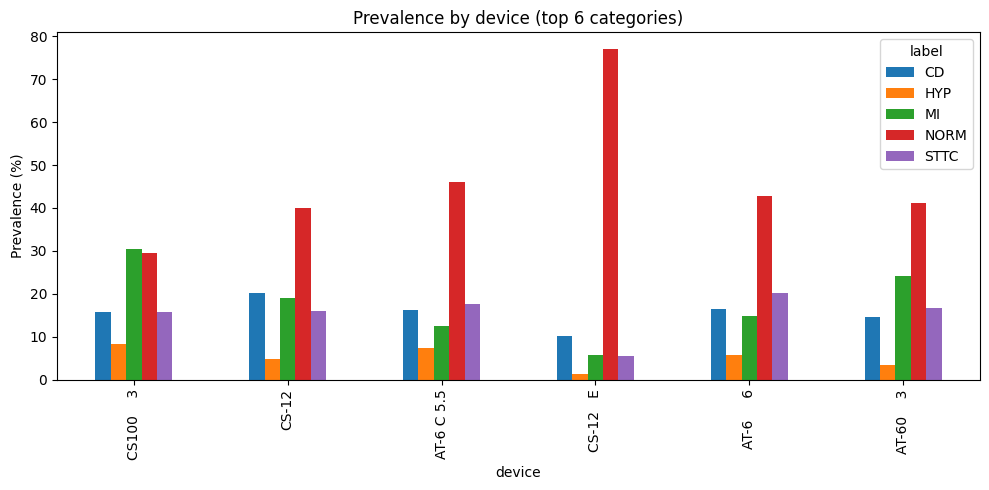

[2025-10-06 21:46:07] device: chi2=2336.7, dof=20, p=0.000e+00


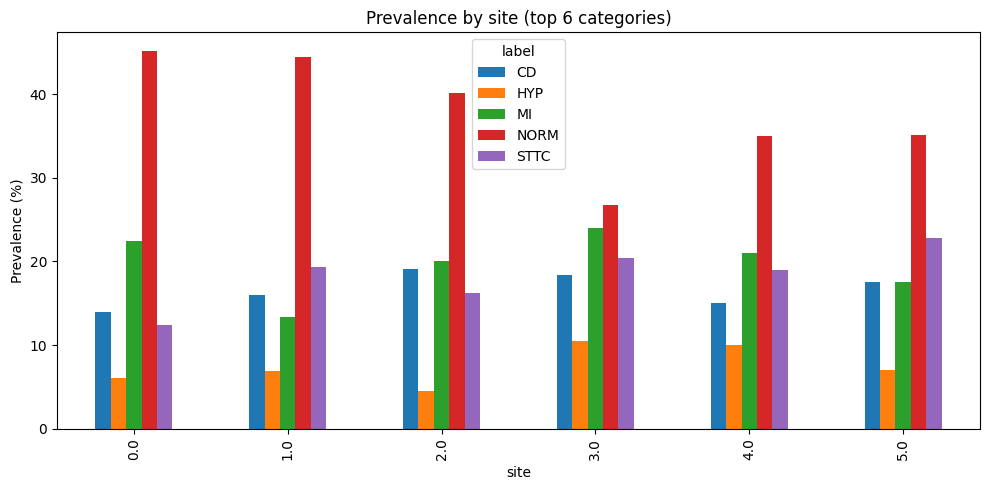

[2025-10-06 21:46:07] site: chi2=450.7, dof=20, p=5.828e-83


In [14]:
def prevalence_bar(df_in, col, top=6):
    counts = pd.crosstab(df_in[col], df_in["label"])
    total = counts.sum(axis=1)
    top_idx = total.sort_values(ascending=False).head(top).index
    sub = counts.loc[top_idx]
    prev = sub.div(sub.sum(axis=1), axis=0) * 100
    prev.plot(kind="bar", figsize=(10,5))
    plt.title(f"Prevalence by {col} (top {top} categories)")
    plt.xlabel(col); plt.ylabel("Prevalence (%)")
    plt.legend(title="label"); plt.tight_layout(); plt.show()
    chi2, p, dof, _ = chi2_contingency(sub.values)
    log(f"{col}: chi2={chi2:.1f}, dof={dof}, p={p:.3e}")

for col in ["device","site"]:
    if col in df_ext.columns:
        prevalence_bar(df_ext, col, top=6)

# 7.7) Collinearity (VIF) — top-variance numeric features

In [15]:
if CFG.get("EDA_SKIP_HEAVY", False):
    print("Skipping VIF (CFG['EDA_SKIP_HEAVY']=True).")
else:
    def vif_table(X: pd.DataFrame):
        vifs = []
        X_ = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)
        if X_.shape[1] < 2 or X_.shape[0] < 5:
            display(pd.DataFrame({"feature": X.columns, "VIF": np.nan}))
        else:
            for col in X_.columns:
                y = X_[col].values
                Xrest = X_.drop(columns=[col]).values
                try:
                    r2 = LinearRegression().fit(Xrest, y).score(Xrest, y)
                except Exception:
                    r2 = np.nan
                vif = np.inf if (r2 is not None and r2 >= 0.999999) else (1.0 / max(1e-12, 1 - (r2 if r2==r2 else 0)))
                vifs.append((col, float(vif)))
            display(pd.DataFrame(vifs, columns=["feature","VIF"]).sort_values("VIF", ascending=False).head(20))
    num_all = df_ext.select_dtypes(include=[np.number])
    var = num_all.var().sort_values(ascending=False)
    cols = var.index[:40] if len(var) > 40 else var.index
    vif_table(num_all[cols])

,feature,VIF
38,L8_std,inf
37,L8_rms,inf
36,L7_std,inf
35,L7_rms,inf
13,L3_kurt,16.708572
31,L3_skew,15.688615
20,L2_skew,10.929975
9,L0_kurt,10.784598
21,L5_skew,10.241322
25,L1_skew,9.861497


# 7.8) PCA visualization — safe fallback

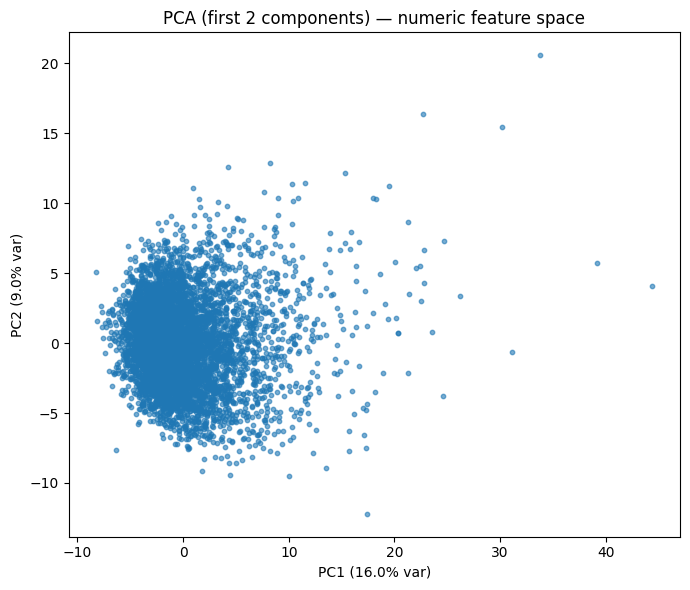

In [16]:
if CFG.get("EDA_SKIP_HEAVY", False):
    print("Skipping PCA (CFG['EDA_SKIP_HEAVY']=True).")
else:
    from sklearn.preprocessing import StandardScaler
    if "preprocessor" in locals() and "X_train" in locals() and "y_train" in locals():
        Xtr = preprocessor.fit_transform(X_train); ytr = y_train.values
        if not isinstance(Xtr, np.ndarray): Xtr = Xtr.toarray()
    else:
        num_cols = df_ext.select_dtypes(include=[np.number]).columns
        Xtr = df_ext[num_cols].replace([np.inf, -np.inf], np.nan).dropna()
        Xtr = StandardScaler().fit_transform(Xtr); ytr = np.zeros(Xtr.shape[0])
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=42)
    emb = pca.fit_transform(Xtr)
    plt.figure(figsize=(7,6))
    plt.scatter(emb[:,0], emb[:,1], s=10, alpha=0.6)
    plt.title("PCA (first 2 components) — numeric feature space")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.tight_layout(); plt.show()

# 8) Leakage‑safe Split (prefer PTB‑XL `strat_fold`)

In [17]:
from sklearn.model_selection import GroupShuffleSplit

df = features_df.copy()
TARGET_COL = "label"

if "strat_fold" in df.columns and df["strat_fold"].notna().all():
    train_mask = df["strat_fold"].astype(int).isin(list(range(1,10)))
    test_mask  = df["strat_fold"].astype(int) == 10
    y_train = df.loc[train_mask, TARGET_COL]
    X_train = df.loc[train_mask].drop(columns=[TARGET_COL,"record_path","scp_codes"], errors="ignore")
    y_test  = df.loc[test_mask,  TARGET_COL]
    X_test  = df.loc[test_mask].drop(columns=[TARGET_COL,"record_path","scp_codes"], errors="ignore")
    log("Using PTB-XL strat_fold split (1–9 → train, 10 → test).")
else:
    groups = df["patient_id"].values if "patient_id" in df.columns else np.arange(len(df))
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(df, df[TARGET_COL], groups))
    y_train = df.iloc[train_idx][TARGET_COL]
    X_train = df.iloc[train_idx].drop(columns=[TARGET_COL,"record_path","scp_codes"], errors="ignore")
    y_test  = df.iloc[test_idx][TARGET_COL]
    X_test  = df.iloc[test_idx].drop(columns=[TARGET_COL,"record_path","scp_codes"], errors="ignore")
    log("Using GroupShuffleSplit by patient_id.")

log(f"Train/Test shapes: {X_train.shape} / {X_test.shape}")

[2025-10-06 21:46:07] Using PTB-XL strat_fold split (1–9 → train, 10 → test).
[2025-10-06 21:46:07] Train/Test shapes: (19230, 121) / (2158, 121)


# 9) Preprocessor (numeric/categorical)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category","bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:  # sklearn<1.2
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])
log(f"Preprocessor — numeric={len(num_cols)}, categorical={len(cat_cols)}")

[2025-10-06 21:46:08] Preprocessor — numeric=106, categorical=15


# 10) Models & Hyperparameter Tuning

[2025-10-06 21:46:08] Using HalvingGridSearchCV (factor=4, aggressive)
[2025-10-06 21:46:08] Probe search on 11538/19230 rows (frac=0.6); final refit on full train.
[2025-10-06 22:48:01] LogReg search total: 3641.8s | CV best F1w=0.6720
[2025-10-06 22:53:54] LinearSVM search total: 353.3s | CV best F1w=0.7242
[2025-10-06 22:57:58] RandomForest search total: 28.9s | CV best F1w=0.6288


,Model,CV F1w (best),CV F1w std,Search time (s),Best params
0,LogReg,0.671990,0.002926,3641.757498,"{""clf__C"": 1}"
1,LinearSVM (search),0.724171,0.000893,353.321044,"{""svm__C"": 0.1, ""svm__tol"": 0.001}"
2,LinearSVM (calibrated),NaN,NaN,215.585488,calibration cv=3
3,RandomForest,0.628843,0.008428,28.874078,"{""clf__class_weight"": ""balanced_subsample"", ""c..."


Saved tuning summary → test/artifacts/tuning_summary_section10.csv


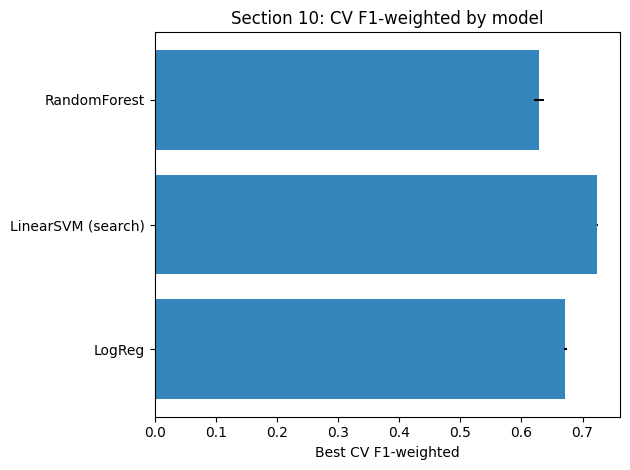

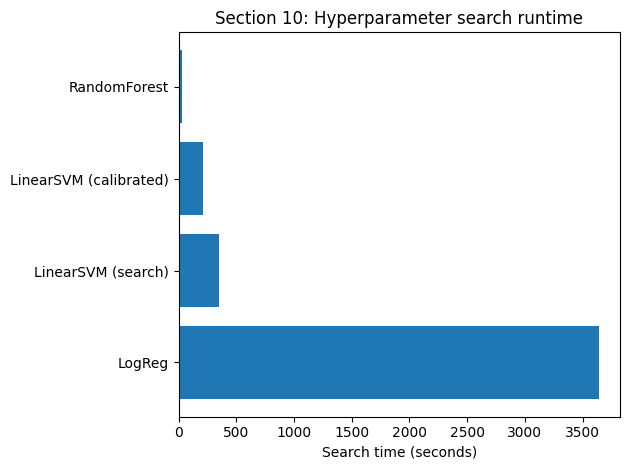

In [19]:
# === 10) MODELS & HYPERPARAMETER TUNING — calibrated SVM, simple table + plots ===
from pathlib import Path
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline as SKPipe

# -------------------- Config (speed vs stability) --------------------
CALIBRATE_SVM = True            # <== always calibrate LinearSVM (left as-is for future use)
FOLDS         = 3               # 3 is stabler than 2; set 2 to go faster
PROBE_FRAC    = 0.60            # fraction of train used for hyperparam search; 1.0 = full
HALVING_FACTOR = 4              # 4 is aggressive and fast; lower to keep more candidates

# -------------------- Halving when available --------------------
try:
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
    from sklearn.model_selection import HalvingGridSearchCV
    USING_HALVING = True
    log(f"Using HalvingGridSearchCV (factor={HALVING_FACTOR}, aggressive)")
except Exception:
    USING_HALVING = False
    HalvingGridSearchCV = None
    log("Using GridSearchCV")

# -------------------- CV folds --------------------
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

# -------------------- Parallelism hygiene --------------------
UNDER_DEBUG = any(k in os.environ for k in ["PYDEVD_LOAD_VALUES_ASYNC","DEBUGPY_LAUNCHER_PORT","PYCHARM_HOSTED"])
N_JOBS = -1 if not UNDER_DEBUG else 1  # full parallelism unless under debugger
# Keep BLAS threads reasonable to avoid oversubscription
os.environ.setdefault("OMP_NUM_THREADS","1")
os.environ.setdefault("OPENBLAS_NUM_THREADS","1")
os.environ.setdefault("MKL_NUM_THREADS","1")
os.environ.setdefault("NUMEXPR_NUM_THREADS","1")

CACHE_DIR = Path(CFG["CACHE_DIR"]); CACHE_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR   = Path(CFG["ART_DIR"]);   ART_DIR.mkdir(parents=True, exist_ok=True)

# -------------------- Probe subset for the *search* (final refit uses full train) --------------------
search_X, search_Y = X_train, y_train
if 0 < PROBE_FRAC < 1.0:
    idx = y_train.sample(frac=PROBE_FRAC, random_state=SEED).index
    search_X, search_Y = X_train.loc[idx], y_train.loc[idx]
    log(f"Probe search on {len(search_X)}/{len(X_train)} rows (frac={PROBE_FRAC}); final refit on full train.")
else:
    log("Probe search uses 100% of training rows.")

def make_search(est, grid):
    common = dict(
        cv=cv, n_jobs=N_JOBS, scoring="f1_weighted",
        verbose=0, error_score=np.nan, return_train_score=False, refit=True  # refit must be bool for string scoring
    )
    if USING_HALVING and HalvingGridSearchCV is not None:
        return HalvingGridSearchCV(est, grid, factor=HALVING_FACTOR, aggressive_elimination=True, **common)
    else:
        return GridSearchCV(est, grid, pre_dispatch="2*n_jobs", **common)

def fit_model(name, pipe, grid):
    t0 = time.perf_counter()
    gs = make_search(pipe, grid)
    gs.fit(search_X, search_Y)                          # search + refit(best) on probe
    best_est = gs.best_estimator_.fit(X_train, y_train) # final refit on full train
    elapsed = time.perf_counter() - t0
    log(f"{name} search total: {elapsed:.1f}s | CV best F1w={getattr(gs,'best_score_',np.nan):.4f}")
    return gs, best_est, elapsed

def extract_best(gsearch):
    out = {"cv_f1w": np.nan, "cv_f1w_std": np.nan, "fit_time_best": np.nan, "params": {}}
    if not hasattr(gsearch, "cv_results_"):
        return out
    cvres = gsearch.cv_results_
    if "mean_test_score" not in cvres:
        return out
    i = int(np.nanargmax(cvres["mean_test_score"]))
    out["cv_f1w"] = float(cvres["mean_test_score"][i])
    out["cv_f1w_std"] = float(cvres.get("std_test_score", [np.nan]*len(cvres["mean_test_score"]))[i])
    out["fit_time_best"] = float(cvres.get("mean_fit_time", [np.nan]*len(cvres["mean_test_score"]))[i])
    out["params"] = gsearch.best_params_
    return out

summary = []

# -------------------- Logistic Regression (sparse-friendly) --------------------
lr_pipe = SKPipe(
    steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(
            solver="saga", penalty="l2", class_weight="balanced",
            max_iter=1500, tol=1e-3, multi_class="auto", random_state=SEED
        ))
    ],
    memory=str(CACHE_DIR)
)
lr_grid = {"clf__C": [1]}
lr_gs, lr_best, lr_time = fit_model("LogReg", lr_pipe, lr_grid)
lr_info = extract_best(lr_gs)
summary.append({
    "Model": "LogReg",
    "CV F1w (best)": lr_info["cv_f1w"],
    "CV F1w std": lr_info["cv_f1w_std"],
    "Search time (s)": lr_time,
    "Best params": json.dumps(lr_info["params"])
})

# -------------------- Linear SVM (search) --------------------
svm_pipe = SKPipe(
    steps=[
        ("prep", preprocessor),
        ("svm", LinearSVC(max_iter=5000, dual=False, class_weight="balanced", random_state=SEED))
    ],
    memory=str(CACHE_DIR)
)
svm_grid = {"svm__C": [0.1, 1], "svm__tol": [1e-3]}
svm_gs, svm_best, svm_time = fit_model("LinearSVM", svm_pipe, svm_grid)
svm_info = extract_best(svm_gs)
summary.append({
    "Model": "LinearSVM (search)",
    "CV F1w (best)": svm_info["cv_f1w"],
    "CV F1w std": svm_info["cv_f1w_std"],
    "Search time (s)": svm_time,
    "Best params": json.dumps(svm_info["params"])
})

# -------------------- Calibration (Platt/sigmoid) — COMMENTED OUT FOR NOW --------------------

from sklearn.calibration import CalibratedClassifierCV
cv_cal = 3 if FOLDS >= 3 else 2
t0 = time.perf_counter()
svm_calibrated = CalibratedClassifierCV(
    estimator=svm_best, method="sigmoid", cv=cv_cal
).fit(X_train, y_train)
cal_time = time.perf_counter() - t0
summary.append({
    "Model": "LinearSVM (calibrated)",
    "CV F1w (best)": np.nan,           # calibration doesn't change CV score from search; we'll evaluate later
    "CV F1w std": np.nan,
    "Search time (s)": cal_time,
    "Best params": f"calibration cv={cv_cal}"
})


# -------------------- Random Forest (compact, strong) --------------------
rf_est = RandomForestClassifier(random_state=SEED, n_jobs=-1, bootstrap=True)
rf_pipe = SKPipe([("prep", preprocessor), ("clf", rf_est)], memory=str(CACHE_DIR))
rf_grid = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [20],
    "clf__min_samples_split": [2],
    "clf__min_samples_leaf": [1],
    "clf__max_features": ["sqrt"],
    "clf__class_weight": ["balanced_subsample"],
}
# Per-tree subsampling (big speedup, similar accuracy)
try:
    rf_est.set_params(max_samples=0.7)
    rf_grid["clf__max_samples"] = [0.7]
except Exception:
    pass
rf_gs, rf_best, rf_time = fit_model("RandomForest", rf_pipe, rf_grid)
rf_info = extract_best(rf_gs)
summary.append({
    "Model": "RandomForest",
    "CV F1w (best)": rf_info["cv_f1w"],
    "CV F1w std": rf_info["cv_f1w_std"],
    "Search time (s)": rf_time,
    "Best params": json.dumps(rf_info["params"])
})

# -------------------- Optional RF + SMOTE (no grid) --------------------
HAS_SMOTE = False
if bool(CFG.get("RUN_SMOTE", False)):
    try:
        from imblearn.pipeline import Pipeline as ImbPipeline
        from imblearn.over_sampling import SMOTE
        rf_smote = ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=SEED)),
            ("clf", RandomForestClassifier(
                random_state=SEED, n_jobs=-1, n_estimators=200,
                class_weight="balanced_subsample", max_features="sqrt"
            ))
        ])
        t0 = time.perf_counter(); rf_smote.fit(X_train, y_train); sm_time = time.perf_counter() - t0
        HAS_SMOTE = True
        summary.append({
            "Model": "RF + SMOTE (fixed)",
            "CV F1w (best)": np.nan, "CV F1w std": np.nan,
            "Search time (s)": sm_time, "Best params": "fixed params"
        })
        log(f"Trained RF + SMOTE (fixed params) in {sm_time:.1f}s")
    except Exception as e:
        log(f"SMOTE skipped: {e}")

# -------------------- Simple table --------------------
tuning_summary = pd.DataFrame(summary)
display(tuning_summary)

# Persist CSV
out_csv = ART_DIR / "tuning_summary_section10.csv"
tuning_summary.to_csv(out_csv, index=False)
print("Saved tuning summary →", out_csv)

# -------------------- Plot 1: CV F1-weighted (with std error bars) --------------------
scores = tuning_summary.dropna(subset=["CV F1w (best)"])
if not scores.empty:
    plt.figure()
    y = np.arange(len(scores))
    plt.barh(y, scores["CV F1w (best)"], xerr=scores["CV F1w std"].fillna(0.0), alpha=0.9)
    plt.yticks(y, scores["Model"])
    plt.xlabel("Best CV F1-weighted")
    plt.title("Section 10: CV F1-weighted by model")
    plt.tight_layout()
    plt.show()

# -------------------- Plot 2: Hyperparameter search runtime (seconds) --------------------
plt.figure()
plt.barh(np.arange(len(tuning_summary)), tuning_summary["Search time (s)"])
plt.yticks(np.arange(len(tuning_summary)), tuning_summary["Model"])
plt.xlabel("Search time (seconds)")
plt.title("Section 10: Hyperparameter search runtime")
plt.tight_layout()
plt.show()

# -------------------- Expose trained best estimators for evaluation --------------------
models = {
    "LogReg": lr_gs,                 # search object with best_estimator_
    "RandomForest": rf_gs
}
# Optional: include the uncalibrated SVM so it’s still evaluated
try:
    models["LinearSVM (uncalibrated)"] = svm_gs.best_estimator_
except Exception:
    pass

if HAS_SMOTE:
    models["RF + SMOTE"] = rf_smote


# 11) Evaluation — metrics, CM, learning curves, calibration, bootstraps, error analysis


=== Dummy (most_frequent) ===
              precision    recall  f1-score   support

          CD      0.000     0.000     0.000       355
         HYP      0.000     0.000     0.000       123
          MI      0.000     0.000     0.000       405
        NORM      0.431     1.000     0.603       931
        STTC      0.000     0.000     0.000       344

    accuracy                          0.431      2158
   macro avg      0.086     0.200     0.121      2158
weighted avg      0.186     0.431     0.260      2158



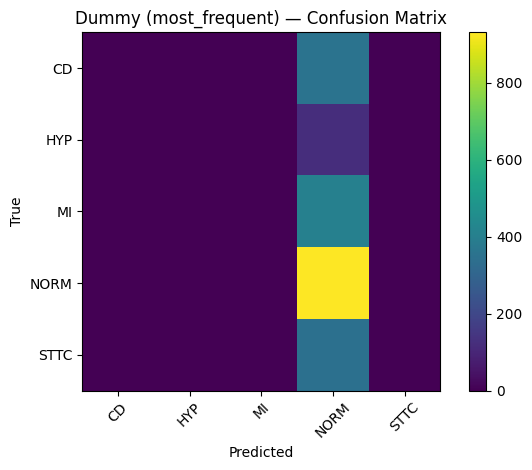


=== LogReg ===
              precision    recall  f1-score   support

          CD      0.495     0.532     0.513       355
         HYP      0.348     0.659     0.455       123
          MI      0.739     0.519     0.610       405
        NORM      0.839     0.760     0.798       931
        STTC      0.494     0.596     0.540       344

    accuracy                          0.646      2158
   macro avg      0.583     0.613     0.583      2158
weighted avg      0.681     0.646     0.655      2158



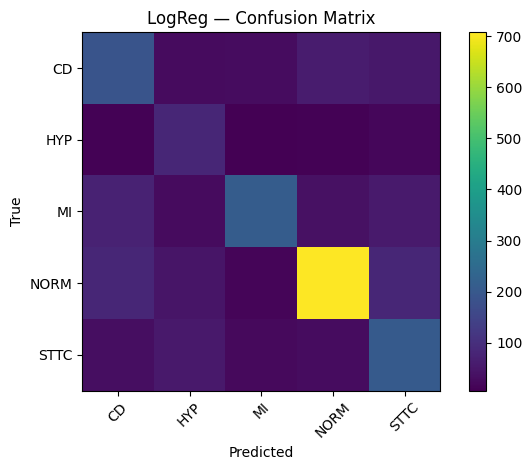


=== RandomForest ===
              precision    recall  f1-score   support

          CD      0.537     0.558     0.547       355
         HYP      0.551     0.398     0.462       123
          MI      0.707     0.452     0.551       405
        NORM      0.693     0.916     0.789       931
        STTC      0.540     0.331     0.411       344

    accuracy                          0.647      2158
   macro avg      0.605     0.531     0.552      2158
weighted avg      0.638     0.647     0.626      2158



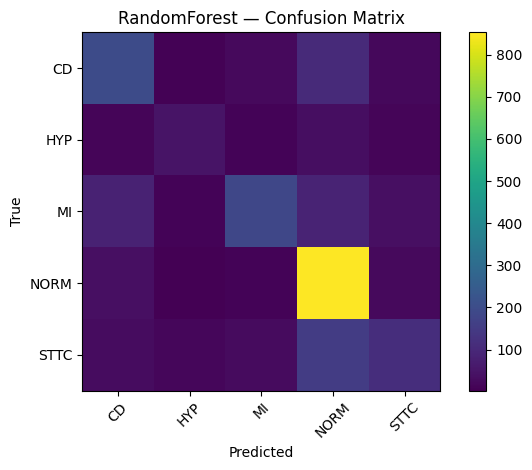


=== LinearSVM (calibrated) ===
              precision    recall  f1-score   support

          CD      0.599     0.572     0.585       355
         HYP      0.522     0.293     0.375       123
          MI      0.734     0.573     0.644       405
        NORM      0.789     0.895     0.838       931
        STTC      0.569     0.625     0.596       344

    accuracy                          0.704      2158
   macro avg      0.642     0.591     0.608      2158
weighted avg      0.697     0.704     0.695      2158



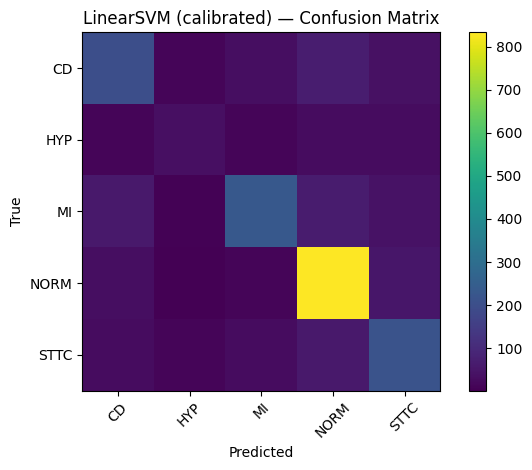

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
3,LinearSVM (calibrated),0.703892,0.642469,0.591418,0.607517,0.695049,0.905282
1,LogReg,0.645505,0.582936,0.613170,0.583091,0.654983,0.867939
2,RandomForest,0.647359,0.605498,0.531117,0.552138,0.625841,0.861268
0,Dummy (most_frequent),0.431418,0.086284,0.200000,0.120557,0.260052,0.500000


In [20]:
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score
)
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build models dict robustly (handles missing calibration)
models = {"LogReg": lr_gs, "RandomForest": rf_gs}
if "svm_calibrated" in locals():
    models["LinearSVM (calibrated)"] = svm_calibrated
elif "svm_best" in locals():
    models["LinearSVM (uncalibrated)"] = svm_best
elif "svm_gs" in locals():
    try:
        models["LinearSVM (uncalibrated)"] = svm_gs.best_estimator_
    except Exception:
        pass
if "HAS_SMOTE" in locals() and HAS_SMOTE:
    models["RF + SMOTE"] = rf_smote

# --------- Baseline dummy ----------
from sklearn.pipeline import Pipeline as SKPipe
dummy_pipe = SKPipe([("prep", preprocessor), ("clf", DummyClassifier(strategy="most_frequent"))])
dummy_pipe.fit(X_train, y_train)

def _get_classes(est):
    cls = getattr(est, "classes_", None)
    if cls is None and hasattr(est, "best_estimator_"):
        cls = getattr(est.best_estimator_, "classes_", None)
    return cls

def _scores_or_none(model, X):
    """
    Returns (scores, classes, kind)
      - scores: (n_samples, n_classes)
      - classes: estimator classes_ order (np.array) or None
      - kind: 'proba' or 'decision' or None
    """
    est_classes = _get_classes(model)
    if hasattr(model, "predict_proba"):
        try:
            s = model.predict_proba(X)
            return s, est_classes, "proba"
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            s = model.decision_function(X)
            if s.ndim == 1:
                s = np.vstack([-s, s]).T  # binary -> two columns
            return s, est_classes, "decision"
        except Exception:
            pass
    return None, None, None

def _align_scores_to_classes(scores, est_classes, target_classes):
    if scores is None or est_classes is None:
        return scores
    est_classes = np.asarray(est_classes)
    target_classes = np.asarray(target_classes)
    pos = {c: i for i, c in enumerate(est_classes)}
    idx = []
    for c in target_classes:
        if c not in pos:
            return None
        idx.append(pos[c])
    return scores[:, idx]

def eval_model(name, model, X_in, y_true, show_cm=True):
    y_pred = model.predict(X_in)
    y_scores, est_classes, score_kind = _scores_or_none(model, X_in)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": np.nan
    }

    # ROC-AUC (align score columns with classes used for binarization)
    if y_scores is not None:
        classes = np.unique(y_true)
        y_bin = label_binarize(y_true, classes=classes)
        y_scores_aligned = _align_scores_to_classes(y_scores, est_classes, classes)
        if y_scores_aligned is not None:
            try:
                auc = roc_auc_score(y_bin, y_scores_aligned, average="macro", multi_class="ovr")
                metrics["roc_auc_ovr_macro"] = float(auc)
            except Exception:
                pass

    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    if show_cm:
        labels = np.unique(y_true)
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        plt.figure()
        plt.imshow(cm, interpolation="nearest")
        plt.title(f"{name} — Confusion Matrix"); plt.colorbar()
        ticks = np.arange(len(labels))
        plt.xticks(ticks, labels, rotation=45); plt.yticks(ticks, labels)
        plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

    return metrics

# --------- Run evaluation ----------
results = [eval_model("Dummy (most_frequent)", dummy_pipe, X_test, y_test)]
for n, m in models.items():
    results.append(eval_model(n, m, X_test, y_test))

res_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
display(res_df)

## 11.1 Learning curves

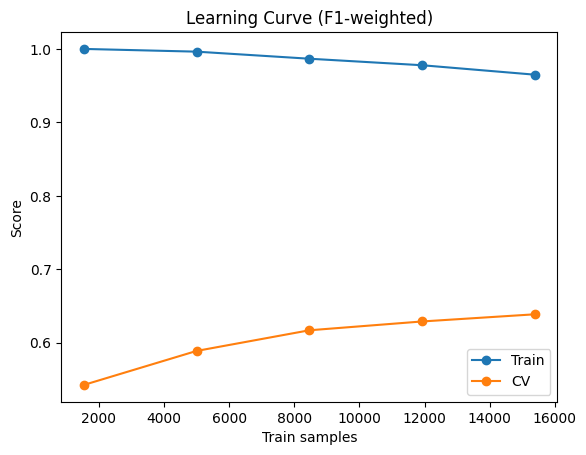

In [21]:
from sklearn.model_selection import learning_curve
try:
    est = rf_gs.best_estimator_
    tsizes = np.linspace(0.1, 1.0, 5)
    train_sizes, train_scores, val_scores = learning_curve(
        est, X_train, y_train, cv=5, n_jobs=-1, scoring="f1_weighted",
        train_sizes=tsizes, shuffle=True, random_state=SEED
    )
    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV")
    plt.title("Learning Curve (F1-weighted)"); plt.xlabel("Train samples"); plt.ylabel("Score"); plt.legend(); plt.show()
except Exception as e:
    log(f"Learning curve skipped: {e}")

## 11.2 Calibration / Reliability

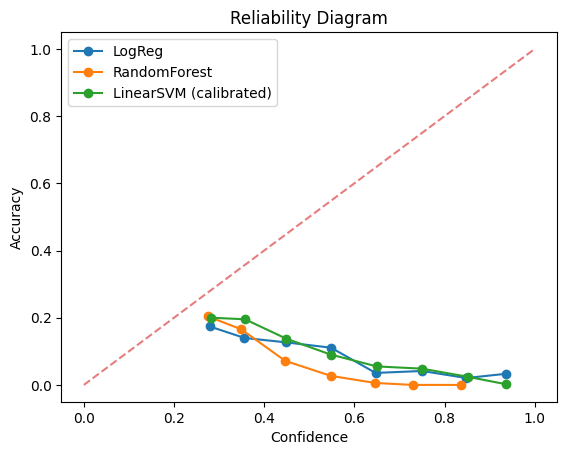

In [22]:
def reliability_diagram(model, X, y, bins=10):
    proba = model.predict_proba(X)
    conf  = proba.max(axis=1)
    preds = proba.argmax(axis=1)
    y_enc = pd.factorize(y)[0]
    correct = (preds == y_enc).astype(int)
    edges = np.linspace(0,1,bins+1); idx = np.digitize(conf, edges)-1
    bin_conf, bin_acc = [], []
    for b in range(bins):
        m = idx==b
        if m.sum()==0: bin_conf.append(np.nan); bin_acc.append(np.nan)
        else:
            bin_conf.append(conf[m].mean()); bin_acc.append(correct[m].mean())
    return np.array(bin_conf), np.array(bin_acc)

plt.figure()
for name, mdl in models.items():
    if hasattr(mdl, "predict_proba"):
        try:
            mconf, macc = reliability_diagram(mdl, X_test, y_test, bins=10)
            plt.plot(mconf, macc, marker="o", label=name)
        except Exception:
            continue
plt.plot([0,1],[0,1],"--", alpha=.6)
plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title("Reliability Diagram"); plt.legend(); plt.show()

## 11.3 Bootstrap CIs (F1-weighted)

In [23]:
rng = np.random.default_rng(SEED)
def bootstrap_f1w(model, X, y, B=200):
    n = len(y); scores = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        Xi = X.iloc[idx] if hasattr(X, "iloc") else X[idx]
        yi = y.iloc[idx] if hasattr(y, "iloc") else y[idx]
        y_hat = model.predict(Xi)
        scores.append(f1_score(yi, y_hat, average="weighted", zero_division=0))
    m = float(np.mean(scores)); lo, hi = np.percentile(scores, [5,95]).tolist()
    return m, lo, hi

for name, model in models.items():
    try:
        m, lo, hi = bootstrap_f1w(model, X_test, y_test, B=200 if not CFG["FAST_RUN"] else 50)
        print(f"{name}: F1_weighted={m:.3f} (95% CI {lo:.3f}–{hi:.3f})")
    except Exception as e:
        log(f"Bootstrap skipped for {name}: {e}")

LogReg: F1_weighted=0.654 (95% CI 0.638–0.671)
RandomForest: F1_weighted=0.627 (95% CI 0.611–0.646)
LinearSVM (calibrated): F1_weighted=0.695 (95% CI 0.679–0.712)


## 11.4 Error analysis

In [24]:
rf = models["RandomForest"]
y_pred = rf.predict(X_test)
labels_unique = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels_unique)

pairs = []
for i in range(len(labels_unique)):
    for j in range(len(labels_unique)):
        if i != j:
            pairs.append((labels_unique[i], labels_unique[j], cm[i, j]))
pairs = sorted(pairs, key=lambda x: -x[2])[:5]
print("Top confused pairs (true→pred, count):", pairs)

mis = (y_test != y_pred)
err_df = pd.DataFrame({"true": y_test[mis], "pred": y_pred[mis]})
display(err_df.head(10))

Top confused pairs (true→pred, count): [('STTC', 'NORM', np.int64(153)), ('CD', 'NORM', np.int64(103)), ('MI', 'NORM', np.int64(87)), ('MI', 'CD', np.int64(86)), ('MI', 'STTC', np.int64(38))]


,true,pred
57,MI,NORM
59,CD,NORM
122,STTC,NORM
148,CD,MI
153,STTC,NORM
161,MI,NORM
195,MI,NORM
203,CD,NORM
256,MI,CD
259,HYP,MI


# 12) Interpretation

In [25]:
from sklearn.inspection import permutation_importance

def get_feature_names(prep):
    try: return prep.get_feature_names_out().tolist()
    except Exception:
        n_feats = prep.fit_transform(X_train).shape[1]
        return [f"f{i}" for i in range(n_feats)]

feat_names = get_feature_names(preprocessor)

# RF impurity importances
try:
    rf_best = models["RandomForest"].best_estimator_
    imp = rf_best.named_steps["clf"].feature_importances_
    idx = np.argsort(imp)[::-1][:20]
    print("Top RF features (impurity):")
    for i in idx:
        print(f"{feat_names[i]:40s} {imp[i]:.4f}")
except Exception as e:
    log(f"RF importance unavailable: {e}")

# Permutation importance
try:
    r = permutation_importance(rf_best, X_test, y_test, n_repeats=5, random_state=SEED, scoring="f1_weighted")
    fn = feat_names if len(feat_names)==len(r.importances_mean) else np.arange(len(r.importances_mean))
    idx = np.argsort(r.importances_mean)[::-1][:20]
    print("\nTop features (permutation):")
    for i in idx:
        print(f"{fn[i]}  {r.importances_mean[i]:.4f} ± {r.importances_std[i]:.4f}")
except Exception as e:
    log(f"Permutation importance skipped: {e}")

# LR coefficients
try:
    lr_best = models["LogReg"].best_estimator_
    coef = lr_best.named_steps["clf"].coef_
    mag = np.mean(np.abs(coef), axis=0)
    idx = np.argsort(mag)[::-1][:20]
    print("\nTop LR features by |coef|:")
    for i in idx:
        print(f"{feat_names[i]:40s} {mag[i]:.4f}")
except Exception as e:
    log(f"LR coefficients unavailable: {e}")

Top RF features (impurity):
cat__infarction_stadium1_unknown         0.0144
num__L10_std                             0.0140
num__L10_rms                             0.0135
num__L3_skew                             0.0131
num__L3_kurt                             0.0128
num__L11_std                             0.0124
num__L10_skew                            0.0119
num__L1_skew                             0.0116
num__L11_rms                             0.0114
num__L9_std                              0.0112
num__L3_rms                              0.0108
num__L3_std                              0.0104
num__L6_rms                              0.0102
num__L10_p25                             0.0101
num__L9_p50                              0.0101
num__L6_skew                             0.0099
num__L1_p50                              0.0098
num__L3_p50                              0.0098
num__L6_std                              0.0098
num__age                                 0.0097

Top feature

# 13) (Optional) Centralized DL Baseline (PyTorch MLP)

In [26]:
if TORCH_OK and not CFG["FAST_RUN"]:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import LabelEncoder

    Xtr_arr = preprocessor.fit_transform(X_train)
    Xte_arr = preprocessor.transform(X_test)
    if not isinstance(Xtr_arr, np.ndarray):
        Xtr_arr = Xtr_arr.toarray(); Xte_arr = Xte_arr.toarray()

    le = LabelEncoder()
    ytr_arr = le.fit_transform(y_train.values); yte_arr = le.transform(y_test.values)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, 128), nn.ReLU(),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Linear(64, out_dim)
            )
        def forward(self, x): return self.net(x)

    model = MLP(Xtr_arr.shape[1], len(np.unique(ytr_arr))).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    train_loader = DataLoader(TensorDataset(torch.tensor(Xtr_arr, dtype=torch.float32),
                                            torch.tensor(ytr_arr, dtype=torch.long)), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(Xte_arr, dtype=torch.float32),
                                           torch.tensor(yte_arr, dtype=torch.long)), batch_size=256, shuffle=False)

    def epoch(loader, train=True):
        model.train() if train else model.eval()
        correct, total = 0, 0
        with torch.set_grad_enabled(train):
            for xb, yb in loader:
                xb, yb = xb.to(device), yb.to(device)
                if train: opt.zero_grad()
                logits = model(xb)
                loss = crit(logits, yb)
                if train: loss.backward(); opt.step()
                pred = logits.argmax(1); correct += (pred==yb).sum().item(); total += xb.size(0)
        return correct / max(total,1)

    for e in range(5):
        tr = epoch(train_loader, True)
        te = epoch(test_loader, False)
        log(f"Epoch {e+1}: train_acc={tr:.3f}  test_acc={te:.3f}")
else:
    log("Skipping DL baseline (Torch unavailable or FAST_RUN=True).")

[2025-10-06 23:01:13] Epoch 1: train_acc=0.648  test_acc=0.691
[2025-10-06 23:01:15] Epoch 2: train_acc=0.770  test_acc=0.702
[2025-10-06 23:01:17] Epoch 3: train_acc=0.847  test_acc=0.689
[2025-10-06 23:01:18] Epoch 4: train_acc=0.915  test_acc=0.682
[2025-10-06 23:01:20] Epoch 5: train_acc=0.956  test_acc=0.680


# 14) (Optional) Federated Learning (Dirichlet non‑IID, weighted FedAvg)

In [27]:
if TORCH_OK and not CFG["FAST_RUN"]:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import LabelEncoder

    prep = preprocessor.fit(X_train, y_train)
    Xtr = prep.transform(X_train); Xte = prep.transform(X_test)
    if not isinstance(Xtr, np.ndarray): Xtr = Xtr.toarray(); Xte = Xte.toarray()

    le = LabelEncoder(); ytr = le.fit_transform(y_train.values); yte = le.transform(y_test.values)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class MLP(nn.Module):
        def __init__(self, in_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(in_dim,128), nn.ReLU(),
                                     nn.Linear(128,64), nn.ReLU(),
                                     nn.Linear(64,out_dim))
        def forward(self, x): return self.net(x)

    def get_weights(m): return [p.detach().cpu().clone() for p in m.parameters()]
    def set_weights(m, ws):
        with torch.no_grad():
            for p,w in zip(m.parameters(), ws): p.copy_(w)
    def avg_weights_weighted(weights_list, sizes):
        total = float(sum(sizes))
        out = [w.clone().mul_(sizes[0]/total) for w in weights_list[0]]
        for ws, n in zip(weights_list[1:], sizes[1:]):
            for i in range(len(out)): out[i].add_(ws[i], alpha=n/total)
        return out

    def dirichlet_partition(y, K=4, alpha=0.3, seed=SEED):
        rng = np.random.default_rng(seed)
        classes = np.unique(y)
        idx_per_client = [[] for _ in range(K)]
        for c in classes:
            idx_c = np.where(y==c)[0]; rng.shuffle(idx_c)
            props = rng.dirichlet([alpha]*K)
            splits = np.cumsum(np.round(props*len(idx_c))).astype(int); splits[-1] = len(idx_c)
            prev = 0
            for k, cut in enumerate(splits):
                idx_per_client[k].extend(idx_c[prev:cut].tolist()); prev = cut
        for k in range(K): rng.shuffle(idx_per_client[k])
        return [np.array(v, dtype=int) for v in idx_per_client]

    K = 4
    splits = dirichlet_partition(ytr, K=K, alpha=0.3)
    sizes = [len(s) for s in splits]

    def make_loader(idx):
        return DataLoader(TensorDataset(torch.tensor(Xtr[idx], dtype=torch.float32),
                                        torch.tensor(ytr[idx], dtype=torch.long)),
                          batch_size=64, shuffle=True)
    client_loaders = [make_loader(s) for s in splits]
    test_loader = DataLoader(TensorDataset(torch.tensor(Xte, dtype=torch.float32),
                                           torch.tensor(yte, dtype=torch.long)), batch_size=256, shuffle=False)

    # Centralized baseline
    base = MLP(Xtr.shape[1], len(np.unique(ytr))).to(device)
    opt = torch.optim.Adam(base.parameters(), lr=1e-3); crit = nn.CrossEntropyLoss()
    for _ in range(5):
        base.train()
        for xb,yb in DataLoader(TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                                             torch.tensor(ytr, dtype=torch.long)), batch_size=64, shuffle=True):
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(base(xb), yb); loss.backward(); opt.step()

    def acc(m, loader):
        m.eval(); c=t=0
        with torch.no_grad():
            for xb,yb in loader:
                xb,yb = xb.to(device), yb.to(device)
                c += (m(xb).argmax(1)==yb).sum().item(); t += xb.size(0)
        return c/max(t,1)

    base_acc = acc(base, test_loader)
    log(f"Centralized MLP acc: {round(base_acc,3)}")

    global_model = MLP(Xtr.shape[1], len(np.unique(ytr))).to(device)
    ROUNDS = 5
    param_bytes = sum(p.numel() for p in global_model.parameters()) * 4
    total_comm_bytes = 0

    for r in range(ROUNDS):
        ws = []
        for loader in client_loaders:
            local = MLP(Xtr.shape[1], len(np.unique(ytr))).to(device)
            set_weights(local, get_weights(global_model))
            opt = torch.optim.Adam(local.parameters(), lr=1e-3); crit = nn.CrossEntropyLoss()
            local.train()
            for xb,yb in loader:
                xb,yb = xb.to(device), yb.to(device)
                opt.zero_grad(); loss = crit(local(xb), yb); loss.backward(); opt.step()
            ws.append(get_weights(local))
            total_comm_bytes += param_bytes  # upload
        set_weights(global_model, avg_weights_weighted(ws, sizes))
        total_comm_bytes += K * param_bytes  # broadcast
        log(f"Round {r+1} — FedAvg test acc: {round(acc(global_model, test_loader), 3)}")

    log(f"Total communication ≈ {total_comm_bytes/1e6:.2f} MB over {ROUNDS} rounds ({K} clients)")
else:
    log("Skipping FL simulation (Torch unavailable or FAST_RUN=True).")

[2025-10-06 23:01:31] Centralized MLP acc: 0.673
[2025-10-06 23:01:33] Round 1 — FedAvg test acc: 0.512
[2025-10-06 23:01:34] Round 2 — FedAvg test acc: 0.553
[2025-10-06 23:01:36] Round 3 — FedAvg test acc: 0.578
[2025-10-06 23:01:38] Round 4 — FedAvg test acc: 0.593
[2025-10-06 23:01:40] Round 5 — FedAvg test acc: 0.602
[2025-10-06 23:01:40] Total communication ≈ 285.53 MB over 5 rounds (4 clients)


# 15) Subgroup Fairness (sex, age bins, device/site)

In [28]:
from sklearn.metrics import f1_score
meta_cols_eval = ["ecg_id","patient_id","age","sex","height","weight","nurse","site","device",
                  "recording_date","report","scp_codes","heart_axis","infarction_stadium1","infarction_stadium2",
                  "validated_by","second_opinion","initial_autogenerated_report","validated_by_human",
                  "baseline_drift","static_noise","burst_noise","electrodes_problems","extra_beats",
                  "pacemaker","strat_fold","record_path"]

test_index = X_test.index
test_meta = df.loc[test_index, meta_cols_eval + ["label"]].copy()
test_meta["pred_RF"]  = models["RandomForest"].predict(X_test)

print("\nWeighted F1 by sex (RF):")
for g, gdf in test_meta.groupby("sex"):
    f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
    print(f"  sex={g}: {f1w:.3f} (n={len(gdf)})")

bins = [-np.inf, 40, 65, np.inf]
labels_bins = ["<40", "40–65", "65+"]
test_meta["age_bin"] = pd.cut(test_meta["age"], bins=bins, labels=labels_bins)

print("\nWeighted F1 by age_bin (RF):")
for g, gdf in test_meta.groupby("age_bin"):
    f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
    print(f"  age_bin={g}: {f1w:.3f} (n={len(gdf)})")

for col in ["site","device","pacemaker"]:
    if col in test_meta.columns:
        print(f"\nWeighted F1 by {col} (RF):")
        for g, gdf in test_meta.groupby(col):
            if len(gdf):
                f1w = f1_score(gdf["label"], gdf["pred_RF"], average="weighted", zero_division=0)
                print(f"  {col}={g}: {f1w:.3f} (n={len(gdf)})")


Weighted F1 by sex (RF):
  sex=0: 0.647 (n=1110)
  sex=1: 0.604 (n=1048)

Weighted F1 by age_bin (RF):
  age_bin=<40: 0.734 (n=310)
  age_bin=40–65: 0.648 (n=883)
  age_bin=65+: 0.564 (n=965)

Weighted F1 by site (RF):
  site=0.0: 0.674 (n=483)
  site=1.0: 0.654 (n=598)
  site=2.0: 0.606 (n=867)
  site=3.0: 0.480 (n=103)
  site=4.0: 0.427 (n=16)
  site=5.0: 0.467 (n=5)
  site=6.0: 0.833 (n=4)
  site=7.0: 0.512 (n=7)
  site=8.0: 0.444 (n=6)
  site=9.0: 0.500 (n=4)
  site=10.0: 0.125 (n=4)
  site=11.0: 0.533 (n=3)
  site=12.0: 0.267 (n=5)
  site=13.0: 0.533 (n=3)
  site=14.0: 0.200 (n=4)
  site=15.0: 0.405 (n=7)
  site=16.0: 1.000 (n=2)
  site=17.0: 0.778 (n=3)
  site=18.0: 1.000 (n=1)
  site=19.0: 1.000 (n=2)
  site=20.0: 0.125 (n=4)
  site=21.0: 1.000 (n=1)
  site=24.0: 1.000 (n=1)
  site=25.0: 0.444 (n=3)
  site=26.0: 1.000 (n=1)
  site=27.0: 1.000 (n=1)
  site=28.0: 0.556 (n=3)
  site=29.0: 0.667 (n=2)
  site=30.0: 1.000 (n=2)
  site=31.0: 0.000 (n=1)
  site=32.0: 0.333 (n=3)
  site

# 16) Reporting & Artifact Bundling

In [29]:
ART_DIR = Path(CFG["ART_DIR"]); ART_DIR.mkdir(parents=True, exist_ok=True)

# Save best models
import joblib
joblib.dump(lr_gs.best_estimator_, ART_DIR / "lr_best.joblib")
joblib.dump(rf_gs.best_estimator_, ART_DIR / "rf_best.joblib")
if "svm_calibrated" in locals():
    joblib.dump(svm_calibrated, ART_DIR / "svm_calibrated.joblib")

# Metrics table
res_path = ART_DIR / "results_table.csv"
pd.DataFrame(locals().get("res_df", pd.DataFrame())).to_csv(res_path, index=False)

# Best params JSON (guard SVM presence)
svm_params = None
if "svm_gs" in locals():
    svm_params = getattr(svm_gs, "best_params_", None)
summary_params = {
    "time": ts(),
    "cfg": CFG,
    "lr_best_params": getattr(lr_gs, "best_params_", None),
    "rf_best_params": getattr(rf_gs, "best_params_", None),
    "svm_best_params": svm_params,
}
with open(ART_DIR / "best_params.json", "w") as f:
    json.dump(summary_params, f, indent=2)

# Freeze environment (best-effort)
try:
    req = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    (ART_DIR / "requirements.txt").write_text(req)
except Exception:
    pass

# Bundle ZIP
ZIP_OUT = Path("test/submission_bundle.zip")
with zipfile.ZipFile(ZIP_OUT, "w", zipfile.ZIP_DEFLATED) as z:
    for p in ART_DIR.glob("*"):
        z.write(p, arcname=str(Path("artifacts") / p.name))
    feat_csv = ROOT / "ptbxl_features.csv"
    if feat_csv.exists():
        z.write(feat_csv, arcname="ptbxl_features.csv")
log(f"Created bundle: {ZIP_OUT}")

[2025-10-06 23:01:45] Created bundle: test/submission_bundle.zip


# 17) Appendix — Raw ECG viewer (misclassified example)

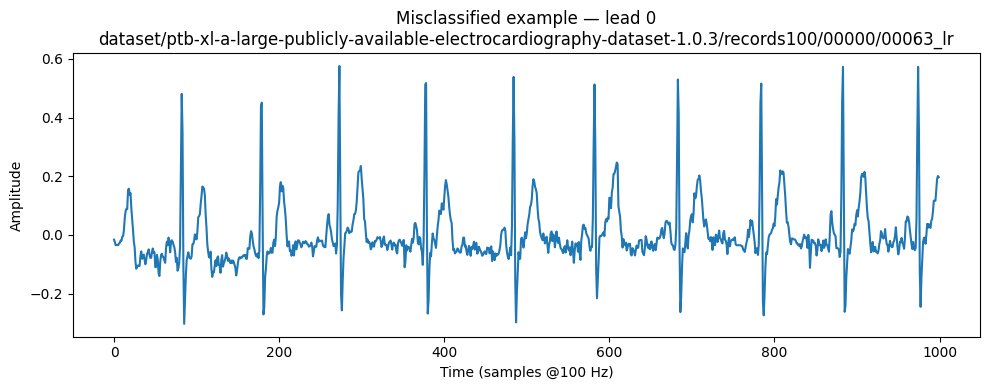

In [30]:
try:
    import wfdb
    rf = models["RandomForest"]; y_pred = rf.predict(X_test)
    mis_mask = (y_test != y_pred)
    if mis_mask.any():
        idx = X_test.index[mis_mask][0]
        rec_path = df.loc[idx, "record_path"]
        sig, meta = wfdb.rdsamp(rec_path)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,4))
        plt.plot(sig[:,0])
        plt.title(f"Misclassified example — lead 0\n{rec_path}")
        plt.xlabel("Time (samples @100 Hz)"); plt.ylabel("Amplitude")
        plt.tight_layout(); plt.show()
    else:
        log("No misclassifications to display.")
except Exception as e:
    log(f"Raw viewer skipped: {e}")